## 📊 train_v2.csv 컬럼 설명

| 컬럼명        | 의미                     |
| ---------- | ---------------------- |
| `msno`     | 고객 고유 식별자(익명화된 고객 ID)  |
| `is_churn` | 고객 이탈 여부(0: 유지, 1: 이탈) |

**참고 사항**

* `msno`는 다른 데이터셋과 고객 정보를 연결할 때 사용하는 기준 컬럼이다.
* `is_churn`은 모델이 예측해야 하는 타겟(정답) 컬럼이다.
* KKBOX 대회에서 이탈은 구독 만료 후 30일 이내에 새로운 유효 구독을 시작하지 않은 경우를 의미한다.
* 본 노트북은 팀에서 추출한 10만 명 표본(`train_100k.csv`) 기준으로 작성됨.

**출처:** Kaggle KKBOX Churn Prediction Challenge — 데이터 설명

https://www.kaggle.com/competitions/kkbox-churn-prediction-challenge/data

In [1]:
import pandas as pd

# csv 불러오기 & 미리보기
df = pd.read_csv("../../data/sampled/train_100k.csv")
df.head() # 고객 식별자(msno)와 이탈여부(is_churn)을 포함

,msno,is_churn
0,9BEEEzxPms9jHREEUNVVw98vqYcjJinOJcL/WeHlb4M=,0
1,nuKiQ/vJS3Olc78nMfSbSHOQEdpCyRcFvTWUkjO66kE=,0
2,kMohbZUdmPB/5M0Vh9sWNYIsIDmbAysozML3gDSIvLQ=,0
3,w5xouqYrDegrRJGTA5+51m5/BqyhQekAW9w1sII1Glg=,0
4,N4eHhn1HQZy8V6CIQcKNAxMoC6QYdT7cwz5yNPnsLm0=,0


In [2]:
# 데이터 크기 확인
df.shape # train_100k.csv는 100,000행, 2개의 컬럼으로 구성

(100000, 2)

In [3]:
# 컬럼, 자료형 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   msno      100000 non-null  object
 1   is_churn  100000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [4]:
# 결측치 확인
df.isnull().sum()

msno        0
is_churn    0
dtype: int64

In [5]:
# 고객 ID(msno) 중복 및 고유 고객 수 확인
# 100,000으로 고객 ID가 한 명당 한 행으로 이루어진 걸 확인
print("중복 고객 ID:", df['msno'].duplicated().sum())
print("고유 고객 수:", df['msno'].nunique())

중복 고객 ID: 0
고유 고객 수: 100000


In [6]:
# 타겟 값 확인 -> 이진분류 타겟
df['is_churn'].unique()

array([0, 1])

In [7]:
# 이탈 고객(is_churn) 수, 비율 확인 
# => 불균형 상태 > 모델평가에서 정확도만 보면 안된다!
df['is_churn'].value_counts()
df['is_churn'].value_counts(normalize=True) * 100  # 비율로 보기

is_churn
0    93.578
1     6.422
Name: proportion, dtype: float64

<Axes: xlabel='is_churn', ylabel='count'>

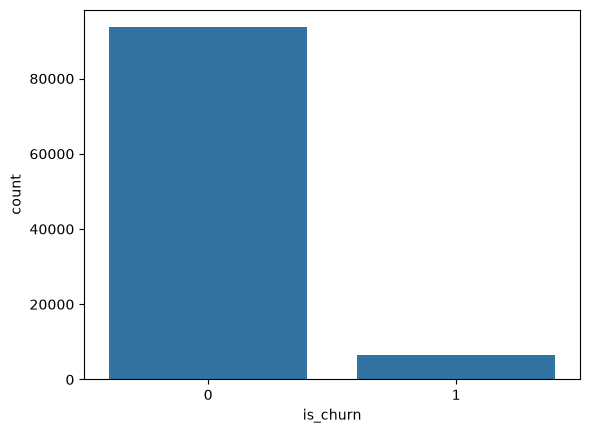

In [8]:
# 이탈 분포 시각화
import seaborn as sns
sns.countplot(x='is_churn', data=df)

## 📊 EDA 결과 해석 — train_100k.csv (10만 명 표본)

### 1. 데이터 구조

* 전체 데이터: **100,000행 × 2컬럼** (`msno`, `is_churn`)
* `msno`: 고객 고유 식별자
* `is_churn`: 이탈 여부 (0: 유지, 1: 이탈)

### 2. 데이터 품질

* 두 컬럼 모두 결측치 0개
* 고객 ID 중복 0개, 고유 고객 수 100,000명
* 고객 1명당 1행으로 구성
* 타겟 값은 0과 1만 존재

### 3. 클래스 불균형 확인

| 구분    | 비율      |
| ----- | ------- |
| 유지(0) | 약 93.6% |
| 이탈(1) | 약 6.4%  |

* 원본(`train_v2.csv`, 유지 91.0% : 이탈 9.0%)과 비교했을 때, 10만 명 표본에서는 **불균형이 오히려 더 심해짐** (이탈 비율 9.0% → 6.4%)
* 모든 고객을 유지로 예측해도 정확도가 약 93.6%이므로 Accuracy 단독 평가는 부적절함 (원본보다 더 강하게 해당)
* 모델링 단계에서 PR-AUC, ROC-AUC, Recall, Precision, F1-score 등을 검토하고 프로젝트 목적에 맞는 평가 지표를 선정해야 함.
* 이탈 비율이 더 낮아진 만큼, 클래스 가중치 조정 및 오버/언더샘플링 기법의 필요성이 원본보다 커짐.

### 4. 다음 단계에 주는 시사점

* `train_100k`는 고객 ID(`msno`)와 이탈 정답(`is_churn`)을 제공하는 기준 테이블.
* `members_100k`, `transactions_100k`, `user_logs_100k`와 고객 ID를 기준으로 결합해야 함.
* 결제·청취 데이터는 고객당 여러 행이 존재할 수 있으므로 고객별 집계 후 결합 필요.
* 이 파일에서는 결측치와 고객 ID 중복 문제가 확인되지 않았으며, 이탈 원인 분석에는 추가 데이터가 필요함.

### 결론

`train_100k.csv`는 고객별 이탈 정답을 제공하는 10만 명 표본 데이터로, 결측치와 고객 ID 중복은 없음. 다만 원본 대비 클래스 불균형이 더 심화되어(이탈 6.4%), 모델 학습·평가 시 이를 반드시 고려해야 하며 표본 추출 방식에 대한 팀 확인이 필요함.